# 11 · Protocolo temporal común V4 multianual

Implementa el **punto 2 del protocolo** `docs/protocolo_lstm_v4_multianual.md`
(revisión 1): la matriz fija, la separación entrenamiento / validación /
calibración / prueba por fecha del objetivo, el canal inactivo, el perfil causal
y la elegibilidad de cada objetivo.

**No entrena, no construye ni carga modelos.** Su salida es la base común que
después consumirán el LSTM y la CNN-1D, más una auditoría que comprueba que no hay
fuga temporal.

| Etapa | Periodo (fecha del objetivo) | Uso |
|---|---|---|
| Ajuste inicial | 2020–2021 | pesos y normalización inicial |
| Validación | 2022 | elegir el número de épocas E |
| Ajuste definitivo | 2020–2022 | reentrenar E épocas, normalización definitiva |
| Calibración | 2023 | p95 por estación |
| Prueba | 2024 · 2025 · 2026 (ene–jul) | evaluación, cada año por separado |

Código: `src/detect/multianual.py` · pruebas: `tests/test_multianual.py`.
Salidas: `results/lstm_v4_multianual_v1/` (carpeta nueva, no sustituye nada de 2025).

In [1]:
import json, platform, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAIZ = Path('..').resolve()
sys.path.insert(0, str(RAIZ))
from src.detect import multianual as m

SAL = RAIZ / 'results/lstm_v4_multianual_v1'
EJ = SAL / 'ejemplos_etapas'
IMG = RAIZ / 'docs/img/lstm_v4_multianual_v1'
for d in (SAL, EJ, IMG):
    d.mkdir(parents=True, exist_ok=True)
pd.set_option('display.width', 200)
print('Protocolo:', m.PROTOCOLO)

Protocolo: v4_multianual_33_p95cal2023_v1


## 1. Fuentes verificadas

Se lee O₃ directamente de cada zip y se compara el SHA-256 del `.xls` interno con
`docs/checksums_2020_2026.txt`. Si un archivo no coincide, el notebook se detiene.

In [2]:
checks = m.leer_checksums(RAIZ / 'docs/checksums_2020_2026.txt')
long, fuentes = m.cargar_o3_zips(RAIZ / 'data/raw', checks)
codigo = {p: m.sha256((RAIZ / p).read_bytes()) for p in
          ['src/detect/multianual.py', 'src/ingest/rama.py', 'docs/protocolo_lstm_v4_multianual.md']}
(SAL / 'fuentes_sha256.json').write_text(json.dumps(dict(datos=fuentes, codigo=codigo), indent=2, ensure_ascii=False) + '\n')
print(pd.DataFrame(fuentes).to_string(index=False))

       zip    archivo                                                           sha256
20RAMA.zip 2020O3.xls 5b0175714c61a83bc679cc366da34a0dbe824369f778448dc1840b70eb378722
21RAMA.zip 2021O3.xls 63fecdd1f74d7a3bfc4e2cc17a168e26b504ba60c0f649fb9bf3a64b6ba87f0c
22RAMA.zip 2022O3.xls 994657201f8ffb46ba49e5d77a3a283f01d5441ad0022754fde36c24c0eb273a
23RAMA.zip 2023O3.xls eb6b8568dff9d89069f98b94c359eec9a61b64910696cf48bf57124b286d6a08
24RAMA.zip 2024O3.xls 57e6011cc1d3909d220c3c6f1ecd716f0ef463fff718126a7ccd81e8744dcfc0
25RAMA.zip 2025O3.xls 91c11b286ba44f8254ca74e0948e22f2a3ff46b12728ef9175141f1fb026a37f
26RAMA.zip 2026O3.xls 5adc51ae739fd33491e9b8616c2cd37c7d68455d8c89783cc2092e301b8e92ab


## 2. Matriz fija: 33 columnas sobre una rejilla horaria continua

Una fila por hora entre 2020-01-01 00:00 y 2026-07-31 23:00 y las 33 columnas de
la referencia de 2025, en el mismo orden. No se eliminan columnas vacías por año
(eso hacía `cargar_matriz` y cambiaría el número de características). El origen de
cada faltante se conserva sólo para auditoría.

In [3]:
valores, origen = m.matriz_fija(long)
print('Forma:', valores.shape, '| columnas en orden de 2025:', list(valores.columns) == m.ESTACIONES)
print('Rejilla continua:', valores.index.equals(pd.date_range(m.INICIO, m.FIN, freq='h')),
      '| duplicados:', valores.index.duplicated().sum())

etapa = m.etapa_de(valores.index)
orig = origen.stack().rename('origen').reset_index()
orig['etapa'] = etapa.reindex(orig['timestamp']).to_numpy()
tabla_origen = orig.groupby(['etapa', 'origen']).size().unstack(fill_value=0).reindex(list(m.ETAPAS))
print('\nOrigen de cada celda por etapa (33 estaciones):')
print(tabla_origen.to_string())
print('\nRenglones ausentes:', sorted(origen.index[(origen == 'renglon_ausente').all(axis=1)].astype(str)))

Forma: (57696, 33) | columnas en orden de 2025: True
Rejilla continua: True | duplicados: 0



Origen de cada celda por etapa (33 estaciones):
origen               centinela_-99  observado  renglon_ausente
etapa                                                         
ajuste_inicial              160075     418877                0
validacion                   63698     225382                0
calibracion                  66653     222427                0
prueba_2024                  66318     223488               66
prueba_2025                  70257     218823                0
prueba_2026_parcial          43434     124470                0

Renglones ausentes: ['2024-01-17 18:00:00', '2024-04-06 23:00:00']


## 3. Etapas por fecha del objetivo

Cada hora pertenece a una sola etapa. La ventana de contexto puede venir de la
etapa anterior (el 1 de enero usa diciembre): es pasado disponible, no fuga,
porque la estación objetivo nunca está entre sus propias entradas.

In [4]:
resumen_etapas = (pd.DataFrame({'etapa': etapa.values, 'ts': valores.index})
                  .groupby('etapa', sort=False)['ts'].agg(['min', 'max', 'count'])
                  .reindex(list(m.ETAPAS)))
print(resumen_etapas.to_string())
print('\nTodas las horas tienen exactamente una etapa:', etapa.notna().all(),
      '| suma de horas == rejilla:', resumen_etapas['count'].sum() == len(valores))

                           min                 max  count
etapa                                                    
ajuste_inicial      2020-01-01 2021-12-31 23:00:00  17544
validacion          2022-01-01 2022-12-31 23:00:00   8760
calibracion         2023-01-01 2023-12-31 23:00:00   8760
prueba_2024         2024-01-01 2024-12-31 23:00:00   8784
prueba_2025         2025-01-01 2025-12-31 23:00:00   8760
prueba_2026_parcial 2026-01-01 2026-07-31 23:00:00   5088

Todas las horas tienen exactamente una etapa: True | suma de horas == rejilla: True


## 4. Canal inactivo y normalización

Un canal sin observaciones en el ajuste se fuerza a valor 0 y máscara 0 en todas las
etapas (§4.1). Se calcula para las dos fases, ajuste inicial (2020–2021) y ajuste
definitivo (2020–2022). La normalización usa sólo esas etapas, nunca 2023–2026.

In [5]:
inactivos_ini = m.canales_inactivos(valores, ('ajuste_inicial',))
inactivos_def = m.canales_inactivos(valores, m.AJUSTE_DEFINITIVO)
print('Canales inactivos — fase inicial:', inactivos_ini, '| fase definitiva:', inactivos_def)

mu_i, sg_i = m.normalizacion(valores, ('ajuste_inicial',), inactivos_ini)
mu_d, sg_d = m.normalizacion(valores, m.AJUSTE_DEFINITIVO, inactivos_def)
norm = pd.DataFrame({'media_inicial': mu_i, 'desv_inicial': sg_i,
                     'media_definitiva': mu_d, 'desv_definitiva': sg_d})
norm['obs_ajuste_inicial'] = valores.loc[m.mascara_etapas(valores.index, ('ajuste_inicial',))].notna().sum()
norm['obs_ajuste_definitivo'] = valores.loc[m.mascara_etapas(valores.index, m.AJUSTE_DEFINITIVO)].notna().sum()
norm.index.name = 'estacion'
norm.to_csv(SAL / 'normalizacion.csv')
print(norm.round(2).to_string())

# Las celdas de 2023–2026 no pueden mover la normalización.
alterada = valores.copy()
alterada.loc['2023-01-01':] += 1000
mu_alt, sg_alt = m.normalizacion(alterada, m.AJUSTE_DEFINITIVO, inactivos_def)
print('\nNormalización inmune a 2023–2026:', np.allclose(mu_alt, mu_d) and np.allclose(sg_alt, sg_d))
entradas = m.entradas_modelo(valores, inactivos_def)

Canales inactivos — fase inicial: ['XAL'] | fase definitiva: ['XAL']
          media_inicial  desv_inicial  media_definitiva  desv_definitiva  obs_ajuste_inicial  obs_ajuste_definitivo
estacion                                                                                                           
ACO               24.47         19.34             26.68            21.37                6614                  13413
AJM               49.81         24.91             44.08            26.66                2490                   7169
AJU               31.67         23.54             34.07            25.03                9850                  15016
ATI               25.73         21.00             26.73            22.17               15903                  23415
BJU               30.08         26.53             30.88            27.76               16257                  23840
CAM               25.78         25.54             25.92            25.93               16609                  23195
CCA

## 5. Cobertura y elegibilidad por objetivo

Ejemplo efectivo = hora con lectura válida del objetivo, base del perfil disponible
y 24 horas previas en la rejilla. Mínimos fijados antes de entrenar: **≥2 000
ejemplos y ≥6 meses** en ajuste inicial, validación y calibración.

In [6]:
cob = m.cobertura_etapas(valores, inactivos_def)
cob.to_csv(SAL / 'cobertura_etapas.csv', index=False)

clases = cob.drop_duplicates('objetivo')[['objetivo', 'clasificacion', 'motivo']].set_index('objetivo')
print(clases['clasificacion'].value_counts().to_string())
print('\nNo principales:')
print(clases[clases.clasificacion != 'principal'].to_string())

piv = cob.pivot(index='objetivo', columns='etapa', values='ejemplos')[list(m.ETAPAS)]
print('\nEjemplos efectivos por objetivo y etapa:')
print(piv.join(clases['clasificacion']).to_string())

clasificacion
principal                 28
baja_representatividad     3
fuera                      2

No principales:
                   clasificacion                                      motivo
objetivo                                                                    
AJM       baja_representatividad      ajuste_inicial: 2489 ejemplos, 4 meses
HGM                        fuera                  sin ejemplos en validacion
INN       baja_representatividad         calibracion: 2950 ejemplos, 5 meses
TLI       baja_representatividad         calibracion: 1509 ejemplos, 3 meses
XAL                        fuera  sin ejemplos en ajuste_inicial, validacion

Ejemplos efectivos por objetivo y etapa:
          ajuste_inicial  validacion  calibracion  prueba_2024  prueba_2025  prueba_2026_parcial           clasificacion
objetivo                                                                                                                
ACO                 6613        6799         6745          

In [7]:
# Contraste con la tabla escrita en el §3.2 del protocolo (antes de generar este archivo).
esperado = {'HGM': 'fuera', 'XAL': 'fuera', 'TLI': 'baja_representatividad',
            'INN': 'baja_representatividad', 'AJM': 'baja_representatividad'}
obs = clases['clasificacion']
diferencias = {s: (esperado.get(s, 'principal'), obs[s]) for s in obs.index if obs[s] != esperado.get(s, 'principal')}
print('Coincide con la tabla del protocolo:', not diferencias, diferencias or '')

print('\nDisponibilidad en prueba (ejemplos):')
prueba = piv[['prueba_2024', 'prueba_2025', 'prueba_2026_parcial']]
print('  sin ejemplos en 2024:', list(prueba.index[prueba.prueba_2024 == 0]))
print('  sin ejemplos en 2025:', list(prueba.index[prueba.prueba_2025 == 0]))
print('  sin ejemplos en 2026:', list(prueba.index[prueba.prueba_2026_parcial == 0]))

resp = cob.groupby('etapa')[['ejemplos', 'base_14d', 'base_historico_hora', 'base_historico_global']].sum().reindex(list(m.ETAPAS))
print('\nOrigen de la base del perfil (todas las estaciones):')
print(resp.to_string())

Coincide con la tabla del protocolo: True 

Disponibilidad en prueba (ejemplos):
  sin ejemplos en 2024: ['ACO']
  sin ejemplos en 2025: []
  sin ejemplos en 2026: ['AJU', 'CHO', 'FAR']

Origen de la base del perfil (todas las estaciones):
                     ejemplos  base_14d  base_historico_hora  base_historico_global
etapa                                                                              
ajuste_inicial         418260    417173                  936                    151
validacion             225382    224749                  633                      0
calibracion            222426    221656                  747                     23
prueba_2024            223488    222719                  769                      0
prueba_2025            218823    218035                  788                      0
prueba_2026_parcial    124470    124095                  375                      0


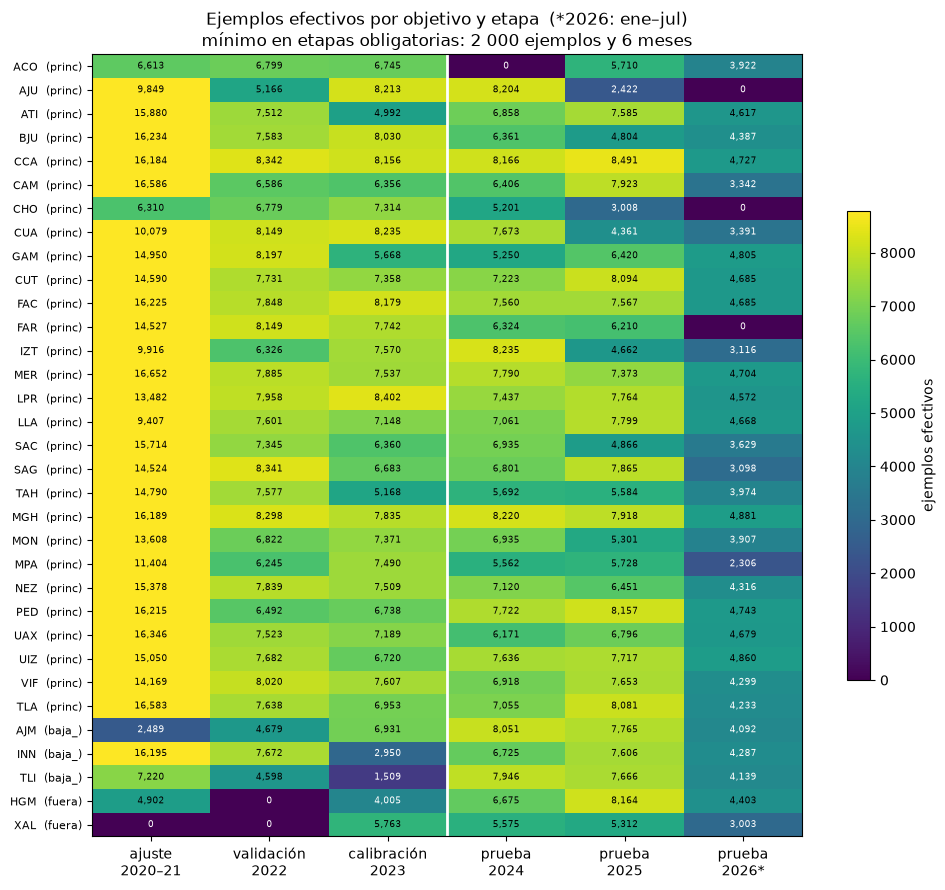

In [8]:
fig, ax = plt.subplots(figsize=(10, 9))
orden = clases.sort_values('clasificacion', key=lambda c: c.map({'principal': 0, 'baja_representatividad': 1, 'fuera': 2})).index
tabla = piv.loc[orden]
im = ax.imshow(tabla.to_numpy(float), aspect='auto', cmap='viridis', vmin=0, vmax=8784)
etiquetas = ['ajuste\n2020–21', 'validación\n2022', 'calibración\n2023', 'prueba\n2024', 'prueba\n2025', 'prueba\n2026*']
ax.set_xticks(range(len(etiquetas)), etiquetas)
ax.set_yticks(range(len(orden)), [f'{s}  ({clases.at[s, "clasificacion"][:5]})' for s in orden], fontsize=8)
for i in range(tabla.shape[0]):
    for j in range(tabla.shape[1]):
        x = tabla.iat[i, j]
        ax.text(j, i, f'{x:,}', ha='center', va='center', fontsize=6.5, color='white' if x < 4400 else 'black')
ax.axvline(2.5, color='w', lw=2)
fig.colorbar(im, ax=ax, shrink=0.6, label='ejemplos efectivos')
ax.set_title('Ejemplos efectivos por objetivo y etapa  (*2026: ene–jul)\n'
             'mínimo en etapas obligatorias: 2 000 ejemplos y 6 meses')
fig.tight_layout()
fig.savefig(IMG / 'cobertura_etapas.png', dpi=150)
plt.show()

## 6. Auditoría temporal

Comprobaciones automáticas, una por fila, guardadas en `auditoria_temporal.csv`.
La de causalidad del perfil se hace sobre datos reales: se suman 1 000 ppb a
todo lo posterior a un instante y se verifica que ninguna base anterior ni la del
propio instante cambie.

In [9]:
aud = []
def check(nombre, ok, detalle=''):
    aud.append(dict(comprobacion=nombre, ok=bool(ok), detalle=str(detalle)))

check('rejilla horaria continua 2020-01-01..2026-07-31', valores.index.equals(pd.date_range(m.INICIO, m.FIN, freq='h')), len(valores))
check('33 columnas en el orden de 2025', list(valores.columns) == m.ESTACIONES)
check('cada hora en exactamente una etapa', etapa.notna().all() and resumen_etapas['count'].sum() == len(valores))
fronteras = [(resumen_etapas['max'].iloc[i], resumen_etapas['min'].iloc[i + 1]) for i in range(len(resumen_etapas) - 1)]
check('etapas consecutivas sin solape ni hueco', all(b - a == pd.Timedelta(hours=1) for a, b in fronteras))
n_ausentes = int((origen == 'renglon_ausente').to_numpy().sum())
check('renglones ausentes de 2024 conservados como faltantes', n_ausentes == 2 * 33, f'{n_ausentes} celdas')
check('ningún valor interpolado: NaN solo donde el origen no es observado',
      (valores.notna() == (origen == 'observado')).to_numpy().all())
check('canal inactivo definitivo = [XAL]', inactivos_def == ['XAL'], inactivos_def)
check('canal inactivo oculto en todas las etapas', entradas['XAL'].isna().all())
check('XAL conserva lecturas para el máximo de red', valores.loc['2023':, 'XAL'].notna().sum() > 0,
      int(valores['XAL'].notna().sum()))
check('normalización inmune a 2023–2026', np.allclose(mu_alt, mu_d) and np.allclose(sg_alt, sg_d))

# Causalidad del perfil sobre datos reales, en las fronteras de etapa
for s in ['CCA', 'PED', 'TLI']:
    p = m.perfil_causal(valores[s])
    for corte in ['2022-01-01 00:00', '2023-01-01 00:00', '2024-01-01 00:00', '2024-05-15 15:00']:
        t = pd.Timestamp(corte)
        alt = valores[s].copy()
        alt[alt.index >= t] += 1000
        pa = m.perfil_causal(alt)
        hasta_t = p.index <= t
        igual = np.allclose(p.loc[hasta_t, 'base'], pa.loc[hasta_t, 'base'], equal_nan=True)
        check(f'perfil causal {s} @ {corte}', igual)

# Ventanas: contexto t-24..t-1, sin la estación objetivo, 24 × 66
for t in ['2022-01-01 00:00', '2024-04-06 23:00', '2024-04-07 05:00']:
    p = m.perfil_causal(valores['CCA'])
    ej = m.ventana_ejemplo(entradas, 'CCA', t, mu_d, sg_d, p, valores)
    t = pd.Timestamp(t)
    ok = (ej['X'].shape == (24, 66) and ej['X'].index.max() == t - pd.Timedelta(hours=1)
          and ej['X'].index.min() == t - pd.Timedelta(hours=24) and 'CCA_valor' not in ej['X'])
    check(f'ventana CCA @ {t} es t-24..t-1, 24×66, sin CCA', ok)

# Contraste con el inventario del notebook 10 (horas válidas por estación y año)
inv = pd.read_csv(RAIZ / 'results/inventario_multianual/cobertura_o3.csv', index_col=0)
cob_anual = valores.groupby(valores.index.year).apply(lambda d: 100 * d.notna().mean()).T.round(2)
cob_anual.columns = cob_anual.columns.astype(str)
inv33 = inv.loc[m.ESTACIONES, cob_anual.columns]
check('cobertura por estación y año == inventario (notebook 10)', np.allclose(cob_anual, inv33, atol=0.011))
check('clasificación == tabla del §3.2 del protocolo', not diferencias, diferencias or '')

auditoria = pd.DataFrame(aud)
auditoria.to_csv(SAL / 'auditoria_temporal.csv', index=False)
print(auditoria.to_string(index=False))
print('\nTODAS LAS COMPROBACIONES:', 'OK' if auditoria.ok.all() else 'FALLAN')

                                                      comprobacion   ok   detalle
                   rejilla horaria continua 2020-01-01..2026-07-31 True     57696
                                   33 columnas en el orden de 2025 True          
                                cada hora en exactamente una etapa True          
                           etapas consecutivas sin solape ni hueco True          
             renglones ausentes de 2024 conservados como faltantes True 66 celdas
ningún valor interpolado: NaN solo donde el origen no es observado True          
                                 canal inactivo definitivo = [XAL] True   ['XAL']
                         canal inactivo oculto en todas las etapas True          
                       XAL conserva lecturas para el máximo de red True     19654
                                  normalización inmune a 2023–2026 True          
                              perfil causal CCA @ 2022-01-01 00:00 True          
                

## 7. Un ejemplo real por etapa (CCA)

Para revisar a mano: la primera hora de cada etapa con ejemplo efectivo. Se guardan
el contexto crudo (ppb, con las fechas), la entrada exacta de 24 × 66 que recibiría
el modelo con la normalización definitiva y un resumen con objetivo, base y su origen.

In [10]:
p_cca = m.perfil_causal(valores['CCA'])
ok_cca = m.ejemplos_validos(valores, 'CCA', p_cca)
filas = []
for nombre in m.ETAPAS:
    t = ok_cca[ok_cca & (etapa == nombre).to_numpy()].index[0]
    ej = m.ventana_ejemplo(entradas, 'CCA', t, mu_d, sg_d, p_cca, valores)
    tag = f"{nombre}_{t:%Y%m%d_%H}"
    ej['crudo'].to_csv(EJ / f'{tag}_contexto_ppb.csv')
    ej['X'].to_csv(EJ / f'{tag}_entrada_24x66.csv', float_format='%.6g')
    filas.append(dict(etapa=nombre, objetivo='CCA', t=t, contexto_desde=ej['X'].index.min(),
                      contexto_hasta=ej['X'].index.max(), original_ppb=ej['original'],
                      base_ppb=round(ej['base'], 4), origen_base=ej['origen_base'],
                      y_desviacion=round(ej['y'], 4),
                      vecinas_con_dato_en_t_menos_1=int(ej['crudo'].iloc[-1].notna().sum())))
ejemplos = pd.DataFrame(filas)
ejemplos.to_csv(EJ / 'resumen.csv', index=False)
print(ejemplos.to_string(index=False))

              etapa objetivo                   t      contexto_desde      contexto_hasta  original_ppb  base_ppb origen_base  y_desviacion  vecinas_con_dato_en_t_menos_1
     ajuste_inicial      CCA 2020-01-02 03:00:00 2020-01-01 03:00:00 2020-01-02 02:00:00          19.0    1.0000         14d       18.0000                              0
         validacion      CCA 2022-01-01 00:00:00 2021-12-31 00:00:00 2021-12-31 23:00:00          10.0   10.0000         14d        0.0000                             26
        calibracion      CCA 2023-01-01 00:00:00 2022-12-31 00:00:00 2022-12-31 23:00:00           4.0    8.8333         14d       -4.8333                             29
        prueba_2024      CCA 2024-01-01 00:00:00 2023-12-31 00:00:00 2023-12-31 23:00:00           9.0    8.4545         14d        0.5455                             24
        prueba_2025      CCA 2025-01-01 00:00:00 2024-12-31 00:00:00 2024-12-31 23:00:00          28.0    7.1818         14d       20.8182            

## 8. Configuración congelada

`protocolo.json` recoge todo lo que determina esta base común. Cualquier cambio en
fechas, columnas, mínimos o reglas exige otra versión del protocolo.

In [11]:
protocolo = dict(
    protocolo=m.PROTOCOLO, revision=1,
    documento='docs/protocolo_lstm_v4_multianual.md',
    rejilla=dict(inicio=str(m.INICIO), fin=str(m.FIN), horas=len(valores)),
    convencion_hora='HORA=1 -> 00:00, HORA=24 -> 23:00 (provisional, sin confirmar con SIMAT)',
    estaciones=m.ESTACIONES, etapas=m.ETAPAS, ajuste_definitivo=list(m.AJUSTE_DEFINITIVO),
    etapas_obligatorias=list(m.OBLIGATORIAS),
    elegibilidad=dict(min_ejemplos=m.MIN_HORAS, min_meses=m.MIN_MESES),
    canales_inactivos=dict(fase_inicial=inactivos_ini, fase_definitiva=inactivos_def),
    entrada=dict(ventana_h=m.VENTANA, n_features=66, orden='32 valores, 32 mascaras, sin, cos',
                 normalizacion='media y desviacion (ddof=1) de las etapas de ajuste; 0 -> 1; relleno 0 tras normalizar'),
    perfil=dict(dias=m.PERFIL_DIAS, respaldo=['14d', 'historico_hora', 'historico_global', 'sin_historia -> excluir']),
    entrenamiento=dict(semilla=42, unidades=64, dropout=0.2, densa=32, lr=1e-3, batch=64, max_epocas=60,
                       early_stopping=dict(monitor='val_loss', paciencia=8, min_delta=0, restaurar=True),
                       shuffle=True, epocas_definitivas='E = primera epoca con menor val_loss en 2022, sin reescalar'),
    calibracion=dict(etapa='calibracion', percentil=95, metodo='linear', alerta='residuo_abs > umbral'),
    umbral_excedencia_ppb=155,
    entorno=dict(python=platform.python_version(), pandas=pd.__version__, numpy=np.__version__,
                 plataforma=platform.platform()),
    estado='base temporal construida y auditada; sin entrenamiento',
)
(SAL / 'protocolo.json').write_text(json.dumps(protocolo, indent=2, ensure_ascii=False, default=str) + '\n')
print(json.dumps({k: protocolo[k] for k in ('protocolo', 'rejilla', 'canales_inactivos', 'elegibilidad', 'estado')},
                 indent=2, ensure_ascii=False, default=str))

{
  "protocolo": "v4_multianual_33_p95cal2023_v1",
  "rejilla": {
    "inicio": "2020-01-01 00:00:00",
    "fin": "2026-07-31 23:00:00",
    "horas": 57696
  },
  "canales_inactivos": {
    "fase_inicial": [
      "XAL"
    ],
    "fase_definitiva": [
      "XAL"
    ]
  },
  "elegibilidad": {
    "min_ejemplos": 2000,
    "min_meses": 6
  },
  "estado": "base temporal construida y auditada; sin entrenamiento"
}


## 9. Conclusiones

**La separación temporal queda construida y auditada; no se entrenó nada.**

- **Matriz:** 57 696 horas × 33 estaciones, sin huecos en la rejilla ni
  duplicados, y con las columnas en el orden de 2025. Las 2 horas sin renglón
  de 2024 (17/ene 18:00 y 06/abr 23:00) entran como faltantes: 66 celdas.
  No se interpoló ningún valor.
- **Etapas:** cada hora pertenece a una sola etapa y las fronteras son
  consecutivas: 17 544 h de ajuste inicial, 8 760 de validación, 8 760 de
  calibración, 8 784 de prueba en 2024, 8 760 en 2025 y 5 088 en 2026 (enero–julio).
- **Causalidad:** sumar 1 000 ppb a todo lo posterior a un instante no cambia
  ninguna base anterior ni la de ese instante. Se probó en CCA, PED y TLI, en tres
  fronteras de etapa y en un día de contingencia. Las ventanas son siempre de
  t−24 a t−1 y nunca incluyen la estación objetivo. La normalización no se mueve
  si se alteran los datos de 2023 a 2026.
- **Canal inactivo:** XAL en las dos fases. Su entrada va oculta en todas las
  etapas, pero sus 19 654 lecturas siguen disponibles para el máximo de la red.
- **Elegibilidad:** 28 objetivos en la referencia principal, 3 de baja
  representatividad (AJM en el ajuste inicial, INN y TLI en la calibración) y 2
  fuera (HGM sin validación; XAL sin ajuste). Coincide exactamente con la tabla
  escrita en el §3.2 **antes** de generar este archivo.
- **Huecos en la prueba:** ACO no tiene ningún ejemplo en 2024; AJU, CHO y FAR
  no tienen en 2026. Se evaluarán en los años donde sí haya datos, sin excluirlos
  de los demás.
- **Perfil:** más del 99.5 % de las bases salen de la regla de 14 días. El
  respaldo por hora cubre de 375 a 936 ejemplos por etapa; el respaldo global
  solo aparece en el arranque de 2020 (151) y en 23 casos de 2023. Ningún
  Solo se pierden lecturas válidas al arranque: las primeras 24 h de 2020 (hasta
  23 por estación) y la primera lectura de una estación sin historia previa
  (1 ejemplo; por ejemplo, la primera de XAL en 2023). Ninguna pérdida en
  validación ni en prueba.
- **Cifras cruzadas:** la cobertura por estación y año coincide con el
  inventario del notebook 10.

**Observación para revisar a mano:** en el primer ejemplo de CCA (2020-01-02
03:00), ninguna de las 32 vecinas tiene dato a las 02:00. Es el hueco de
madrugada de toda la red (`HORA` 1–3). Ese ejemplo es válido y el modelo lo
recibirá con máscara 0, pero muestra con qué frecuencia el contexto inmediato
llega vacío a esas horas.

**Siguiente paso del protocolo (§5):** una ruta de entrenamiento nueva con
validación externa en 2022 y ajuste de E épocas fijas. `entrenar()` no se modifica.